In [1]:
# importing some basic libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
dataset= pd.read_csv("train.csv")
dataset.head()
dataset_duplicate=dataset.copy() #duplicating the data so original data is not destroyed

In [3]:
#Collecting some basic idea about the data
print("--"*10,"Basic Data Overview" ,"--"*10,"\n")

shape=dataset_duplicate.shape
print("info of the dataset :\n")

info=dataset_duplicate.info()
print("\n")
unique_login_frequency=dataset_duplicate["Login_Frequency"].unique()

median_usage_time =dataset_duplicate["Daily_Usage_Mins"].median()
mean_usage_time   =dataset_duplicate["Daily_Usage_Mins"].mean()

print("Shape of the dataset :", shape)
print("\n")

print("unique login terms of the dataset :", unique_login_frequency)
print("\n")
print("median_usage_time:",median_usage_time)
print("mean_usage_time:",mean_usage_time)

-------------------- Basic Data Overview -------------------- 

info of the dataset :

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 8 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   Customer_ID          2000 non-null   object
 1   Name                 2000 non-null   object
 2   Email                2000 non-null   object
 3   Account_Age_Days     2000 non-null   int64 
 4   Login_Frequency      2000 non-null   object
 5   Daily_Usage_Mins     2000 non-null   int64 
 6   Last_Support_Ticket  2000 non-null   object
 7   Churn                2000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 125.1+ KB


Shape of the dataset : (2000, 8)


unique login terms of the dataset : ['Weekly' 'Daily' 'Rarely']


median_usage_time: 30.0
mean_usage_time: 36.161



### From the overview we drew some insights : 

#### 1. Key Features are the account age , Usage time , frequency of using the service
#### 2. among all the users the majority uses the service ~30 mins a day
#### 3. the following data has no null values comprising of object and int data types

In [4]:
dataset_duplicate.describe()

,Account_Age_Days,Daily_Usage_Mins,Churn
count,2000.000000,2000.0000,2000.000000
mean,560.969500,36.1610,0.368500
std,317.349495,29.1486,0.482519
min,1.000000,1.0000,0.000000
25%,287.750000,11.0000,0.000000
50%,565.000000,30.0000,0.000000
75%,840.000000,53.0000,1.000000
max,1094.000000,119.0000,1.000000


In [5]:
dataset_duplicate=dataset_duplicate.drop(columns=["Customer_ID","Name","Email","Last_Support_Ticket"],axis=1) #removing unwanted features 

In [6]:
dataset_duplicate.head()

,Account_Age_Days,Login_Frequency,Daily_Usage_Mins,Churn
0,790,Weekly,28,0
1,399,Daily,28,1
2,646,Daily,110,0
3,113,Weekly,21,0
4,322,Weekly,7,1


In [7]:
age=dataset_duplicate["Account_Age_Days"]


In [8]:

count_30=0
count_90=0
count_900=0
count_180=0
count_700=0
count_365=0
count_365_greater=0
age=dataset_duplicate["Account_Age_Days"]
for i in range(1,2000):
    if(age[i]<=30):
        count_30=count_30+1
    elif(age[i]<=180):
        count_180=count_180+1
    
    elif(age[i]<=365):
        count_365=count_365+1
    elif(age[i]<=700):
        count_700=count_700+1
    elif(age[i]<=900):
        count_900=count_900+1
    
print(count_30)
print(count_180)
print(count_365)

print(count_700)
print(count_900)

48
268
322
601
387


In [9]:
dataset_duplicate.columns

Index(['Account_Age_Days', 'Login_Frequency', 'Daily_Usage_Mins', 'Churn'], dtype='object')

## DATA VISUALISATION

<Axes: ylabel='count'>

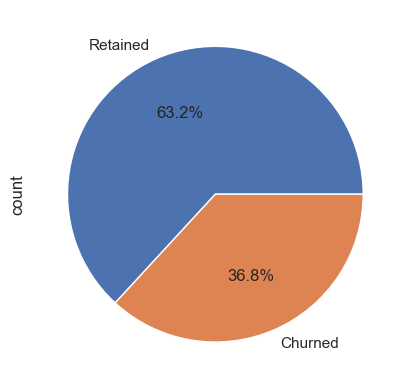

In [50]:
dataset_duplicate['Churn'].value_counts().plot(kind='pie', autopct='%1.1f%%', labels=['Retained','Churned'])

Mean acc age Of Active Users:  568.492478226445 days
Number of retained users:  1263
Mean Usage Time Of Active Users:  47.68250197941409 Mins


Number of Churned users:  737
Mean Usage Time Of Active Users:  16.416553595658073 Mins
Mean acc age Of inActive Users:  548.0773405698778 days




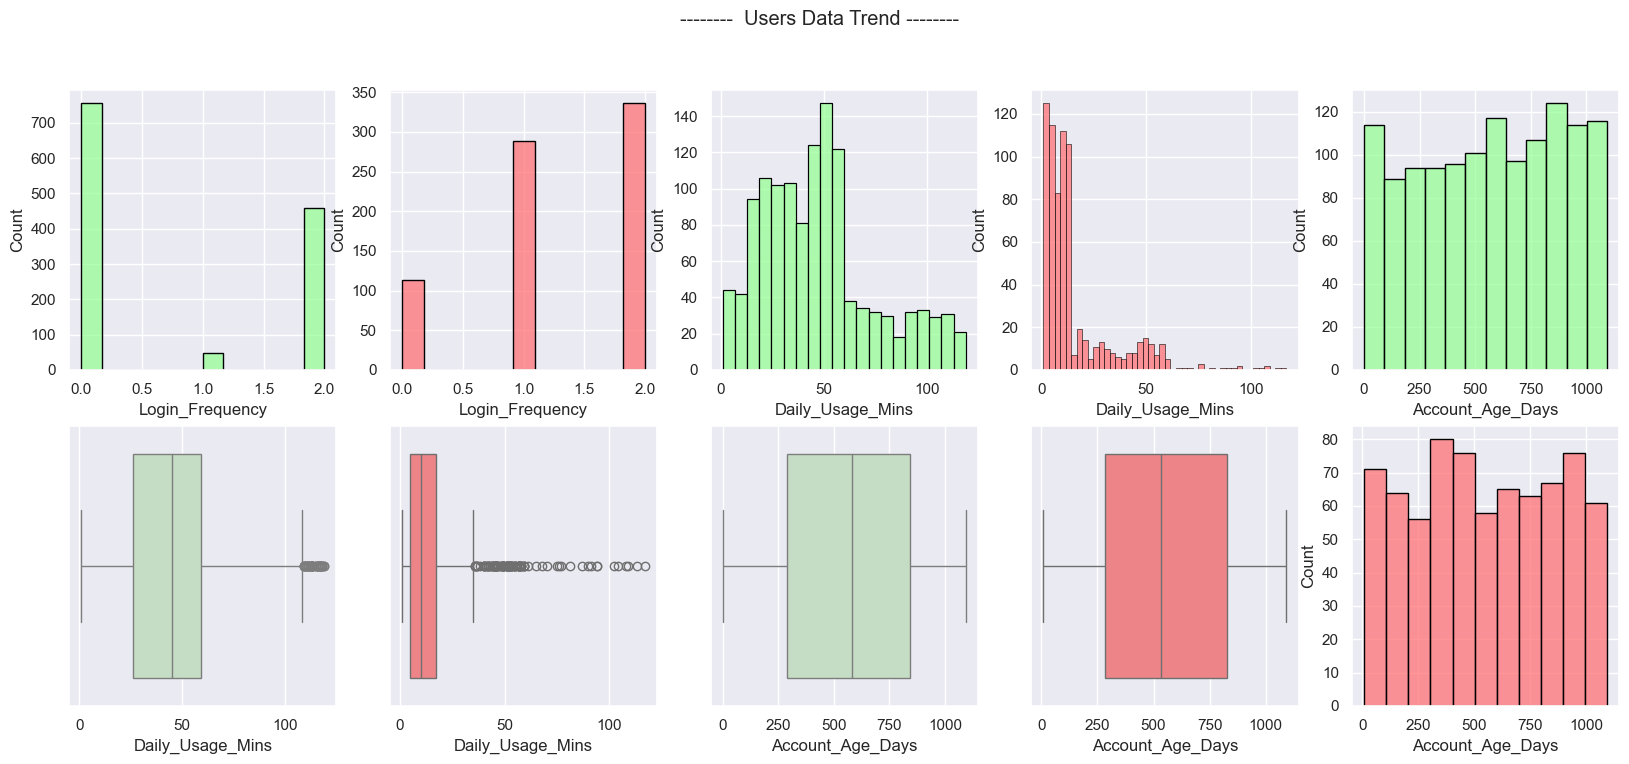

In [103]:
active=dataset_duplicate.query("Churn == 0").count()
active_dataset=dataset_duplicate.query("Churn == 0") #seprating users on the basis of churn to visualise the diffent patterns among the customers
mean_usage_time=active_dataset["Daily_Usage_Mins"].mean()
mean_acc_age=active_dataset["Account_Age_Days"].mean()


print("Number of retained users: ",  active.Churn)
print("Mean Usage Time Of Active Users: ",  mean_usage_time ,"Mins")
print("Mean acc age Of Active Users: ",  mean_acc_age ,"days")
print("\n")

inactive_dataset=dataset_duplicate.query("Churn == 1")
inactive=dataset_duplicate.query("Churn == 1").count()
mean_usage_time_inactive=inactive_dataset["Daily_Usage_Mins"].mean()
mean_acc_age_inactive=inactive_dataset["Account_Age_Days"].mean()
median_acc_age_inactive=inactive_dataset["Account_Age_Days"].median()

print("Number of Churned users: ",  inactive.Churn)
print("Mean Usage Time Of Active Users: ",  mean_usage_time_inactive ,"Mins")
print("Mean acc age Of inActive Users: ",  mean_acc_age_inactive ,"days")
print("\n")


fig, axes = plt.subplots(2, 5, figsize=(20, 8))
sns.color_palette("viridis")
sns.histplot(
    data=active_dataset,
    x= "Login_Frequency",
    edgecolor="black",
    color="#98FF98",
    
    ax=axes[0][0]
)
sns.histplot(
    data=inactive_dataset,
    x= "Login_Frequency",
    edgecolor="black",
    color="#FF7276",
    
    ax=axes[0][1]
)

sns.histplot(
    data=active_dataset,
    x= "Daily_Usage_Mins",
    edgecolor="black",
    color="#98FF98",
    ax=axes[0][2]
)
sns.histplot(
    data=inactive_dataset,
    x= "Daily_Usage_Mins",
    edgecolor="black",
    color="#FF7276",
    ax=axes[0][3]
)
sns.boxplot(
    data=active_dataset,
    x= "Daily_Usage_Mins",
    color="#C1E1C1",
    ax=axes[1][0]
)
sns.boxplot(
    data=inactive_dataset,
    x= "Daily_Usage_Mins",
    color="#FF7276",
    ax=axes[1][1]
)

sns.boxplot(
    data=active_dataset,
    x= "Account_Age_Days",
    color="#C1E1C1",
    ax=axes[1][2]
)
sns.boxplot(
    data=inactive_dataset,
    x= "Account_Age_Days",
    color="#FF7276",
    ax=axes[1][3]
)

sns.histplot(
    data=active_dataset,
    x= "Account_Age_Days",
    edgecolor="black",
    color="#98FF98",
    
    ax=axes[0][4]
)

sns.histplot(
    data=inactive_dataset,
    x= "Account_Age_Days",
    edgecolor="black",
    color="#FF7276",
    ax=axes[1][4]
)
fig.suptitle("--------  Users Data Trend --------",)
plt.tight_layout
plt.show()

### ------------ Insights from positive and negative users data ----------
####  1. Retained Customers uses the app majorly on daily basis , where as majority churned customers uses the services rarely and weekly
####  2. From the box plot of Account age data we found no outliers for both the division of customers 
####  3. Regular users have more median usage mins but usage mins can solely not be used as a differentiator becuz we can se multiple outliers
####  4. retained users majorly spend ~50-60 min on the app/services whereas churned customers spent around ~1-25 min 

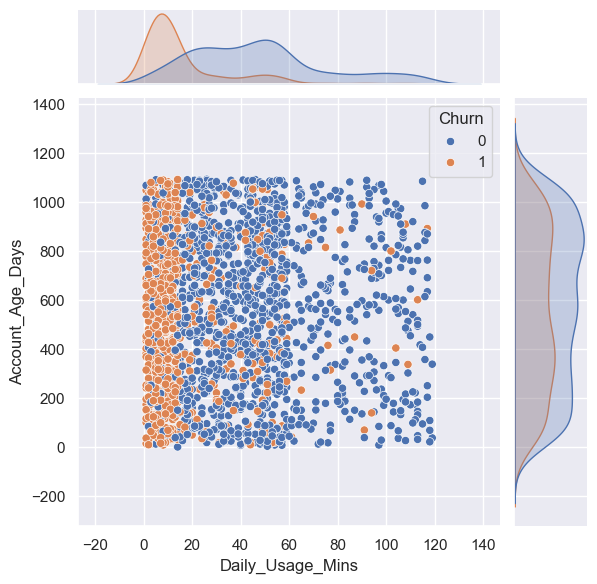

In [11]:
sns.set_theme(style="darkgrid")
sns.jointplot(
    data= dataset_duplicate, 
    x="Daily_Usage_Mins",
    y="Account_Age_Days",
    hue="Churn",
    #style="Churn"
)

### -------------- ACCOUNT AGE VS DAILY USAGE MINS ---------------
#### 1. across the account age diversification daily usage of retined customer occupies the area where daily usage min is high 
#### 2. Retained customers have a uniform spread over usage time whereas churned customers usually fall under a specific cluster as seen in the chart with some outliers

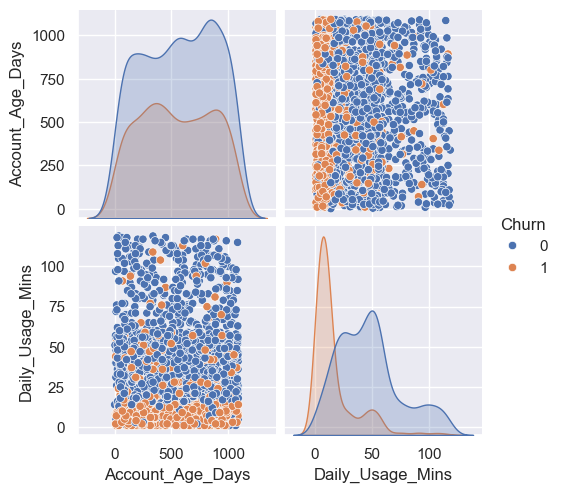

In [12]:
sns.pairplot(data=dataset_duplicate,hue="Churn")

<Axes: xlabel='Account_Age_Days', ylabel='Count'>

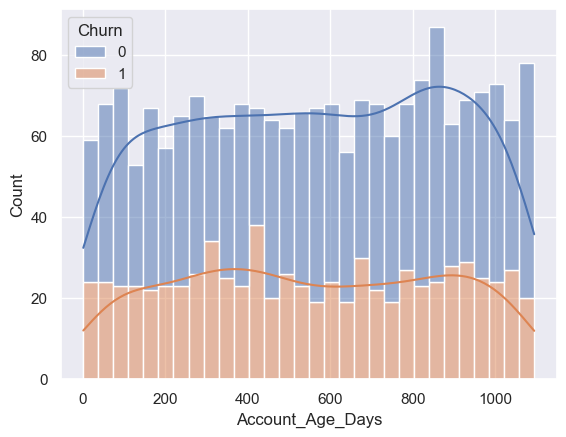

In [13]:
fig , ax= plt.subplots()

sns.histplot(
    data=dataset_duplicate,
    x="Account_Age_Days",
    bins=30,
    kde=True,
    multiple="stack",
    hue="Churn",
    ax=ax
)

<Axes: xlabel='Daily_Usage_Mins', ylabel='Count'>

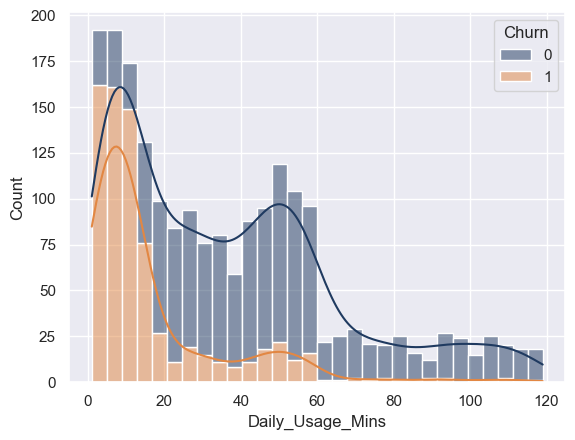

In [14]:
fig , ax= plt.subplots()

sns.histplot(
    data=dataset_duplicate,
    x="Daily_Usage_Mins",
    bins=30,
    hue="Churn",
    ax=ax,
    multiple="stack",
    palette=["#1F3A60", "#E28743"],
    kde=True)

In [15]:
test_data=pd.read_csv("test_.csv")
test_data=test_data.drop(columns=["Customer_ID","Name","Email","Last_Support_Ticket"],axis=1)
X_test=test_data.drop("Churn",axis=1)
y_test=test_data["Churn"]


In [16]:

import pandas as pd
from sklearn.preprocessing import OrdinalEncoder

# 1. Ensure columns are treated as strings to avoid the ValueError
dataset_duplicate['Login_Frequency'] = dataset_duplicate['Login_Frequency'].astype(str)
X_test['Login_Frequency'] = X_test['Login_Frequency'].astype(str)

# 2. Define your explicit order
sizes = ['Daily', 'Rarely', 'Weekly']
enc = OrdinalEncoder(categories=[sizes])

# 3. FIT and TRANSFORM the training set
dataset_duplicate['Login_Frequency'] = enc.fit_transform(dataset_duplicate[['Login_Frequency']])

# 4. ONLY TRANSFORM the test set 
X_test['Login_Frequency'] = enc.transform(X_test[['Login_Frequency']])

In [17]:
X=dataset_duplicate.drop("Churn",axis=1)
y=dataset_duplicate["Churn"]


C:\Users\AVNEET\AppData\Local\Temp\ipykernel_3052\394100556.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  churn_by_bin = dataset_duplicate.groupby('Bin')['Churn'].mean()


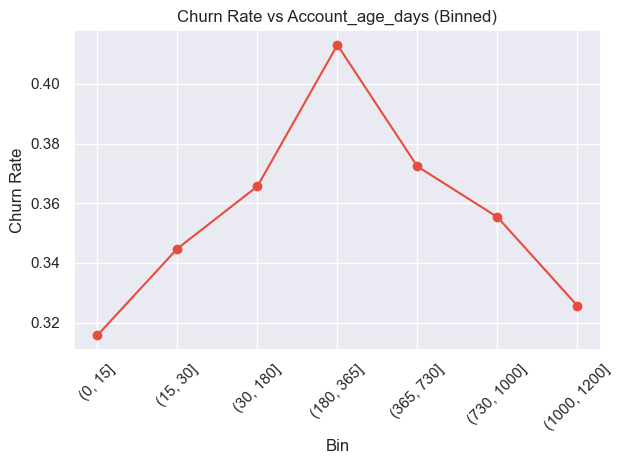

In [18]:
dataset_duplicate['Bin'] = pd.cut(dataset_duplicate['Account_Age_Days'], bins=[0,15,30,180,365,730,1000,1200])   

churn_by_bin = dataset_duplicate.groupby('Bin')['Churn'].mean()

churn_by_bin.plot(kind='line', marker='o', color='#e74c3c')
plt.title('Churn Rate vs Account_age_days (Binned)')
plt.ylabel('Churn Rate')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### ------------ CHURN RATE VS ACCOUNT AGE -----------
#### 1. Customers who spent less then 1 month on the service shows higher churn rate demonstrating high risk of losing the customers in thi range
#### 2. This trend shows increase till around 6 months after that the customers usually stay and the churn rate decreaes 
#### 3. Customers spend over 1 year show much less Churn rate -- demonstrating that the service has gained the confidence
#### 4. Similarly as the trend follows for over 2 years reatined customers as well

C:\Users\AVNEET\AppData\Local\Temp\ipykernel_3052\2798090393.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  churn_by_bin = dataset_duplicate.groupby('Bin')['Churn'].mean()


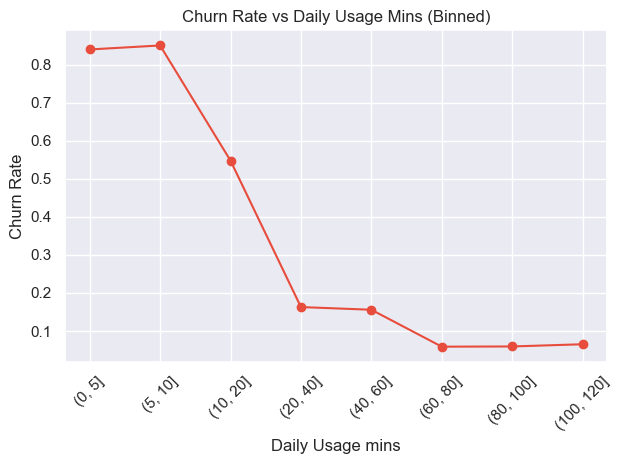

In [46]:
dataset_duplicate['Bin'] = pd.cut(dataset_duplicate['Daily_Usage_Mins'], bins=[0,5,10,20,40,60,80,100,120])  
churn_by_bin = dataset_duplicate.groupby('Bin')['Churn'].mean()

churn_by_bin.plot(kind='line', marker='o', color='#e74c3c')
plt.title('Churn Rate vs Daily Usage Mins (Binned)')
plt.ylabel('Churn Rate')
plt.xlabel('Daily Usage mins')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

C:\Users\AVNEET\AppData\Local\Temp\ipykernel_3052\2758780234.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  churn_by_bin=dataset_duplicate.groupby('Bin')['Churn'].mean().plot(kind='bar')


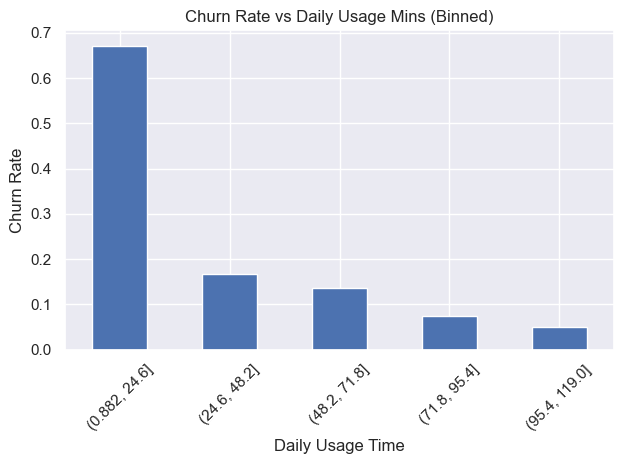

In [51]:
dataset_duplicate['Bin'] = pd.cut(dataset_duplicate['Daily_Usage_Mins'], bins=5)   # or pd.qcut for equal-sized groups

churn_by_bin=dataset_duplicate.groupby('Bin')['Churn'].mean().plot(kind='bar')
churn_by_bin.plot(kind='bar', color='#e74c3c')
plt.title('Churn Rate vs Daily Usage Mins (Binned)')
plt.ylabel('Churn Rate')
plt.xlabel('Daily Usage Time')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### CHURN RATE VS DAILY USAGE MINS
#### -- Churn rate significantly drops when the daily usage min is greater then ~40 min as seen in previous charts as well


C:\Users\AVNEET\AppData\Local\Temp\ipykernel_3052\4043340216.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  churn_by_bin = dataset_duplicate.groupby('Bin')['Churn'].mean()


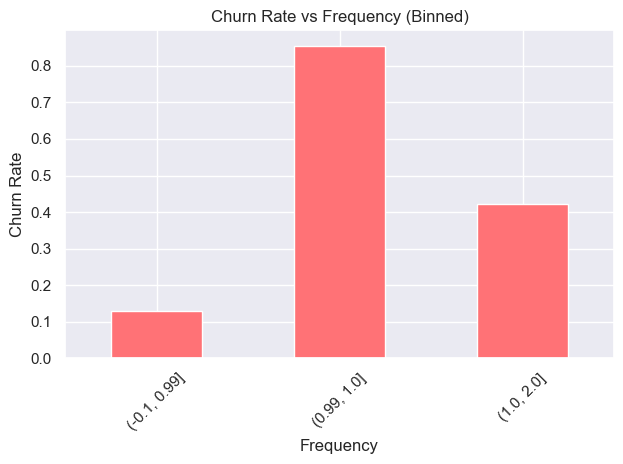

In [48]:
dataset_duplicate['Bin'] = pd.cut(dataset_duplicate['Login_Frequency'], bins=[-0.1,0.99,1,2])   # or pd.qcut for equal-sized groups

churn_by_bin = dataset_duplicate.groupby('Bin')['Churn'].mean()

churn_by_bin.plot(kind='bar', color="#FF7276")
plt.title('Churn Rate vs Frequency (Binned)')
plt.ylabel('Churn Rate')
plt.xlabel('Frequency')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

<Axes: >

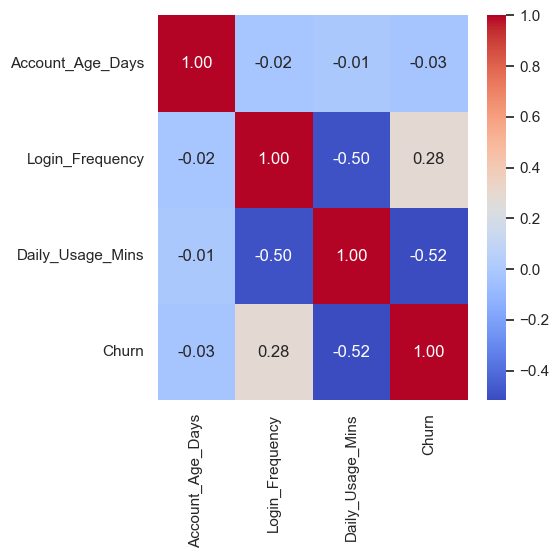

In [23]:
num_cols= dataset_duplicate.select_dtypes(include="number")
corr_matrix  =num_cols.corr()
plt.figure(figsize=(5,5))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

In [24]:
corr_matrix  =num_cols.corr()
corr_matrix

,Account_Age_Days,Login_Frequency,Daily_Usage_Mins,Churn
Account_Age_Days,1.000000,-0.019696,-0.005073,-0.031040
Login_Frequency,-0.019696,1.000000,-0.497883,0.284282
Daily_Usage_Mins,-0.005073,-0.497883,1.000000,-0.517569
Churn,-0.031040,0.284282,-0.517569,1.000000


#### ----------- CORELATION HEATMAP -----------
#### Thier is a direct dependence between churn and login frequency 
#### Whearas thier is negative reation bw other parameters with churn
#### Churn has nearly zero dependence on account age days
#### Churn has an indirct variation with daily usage min which shows more usage time -- less churn possibility

In [25]:
X_test.head()

,Account_Age_Days,Login_Frequency,Daily_Usage_Mins
0,269,0.0,43
1,439,1.0,9
2,18,1.0,1
3,405,0.0,22
4,24,0.0,88


In [26]:
#X_test['Login_Frequency'] = X_test['Login_Frequency'].astype(str)
#X_test['Login_Frequency'] = enc.transform(X_test[['Login_Frequency']])

## MODEL TRAINING -------------

In [27]:
from sklearn.linear_model import LogisticRegression
lr=LogisticRegression(max_iter=1000 , class_weight="balanced",random_state=42)
lr.fit(X,y)
y_pred=lr.predict(X_test)


In [28]:
print(X_test.dtypes)

Account_Age_Days      int64
Login_Frequency     float64
Daily_Usage_Mins      int64
dtype: object


In [63]:
from sklearn.metrics import confusion_matrix,accuracy_score,precision_score,recall_score ,f1_score
from sklearn.metrics import classification_report
from sklearn.metrics import roc_auc_score

print("Precision:", precision_score(y_test,y_pred))
print("\t")
print("Recall:",recall_score(y_test,y_pred))
print("\t")
print("f1:",f1_score(y_test,y_pred))
print("\t")
print("accuracy:",accuracy_score(y_test,y_pred))
print("\t")
print("confusion_matrix:\n",confusion_matrix(y_test,y_pred))
print("\t")
print("roc_auc_score:\n",roc_auc_score(y_test,y_pred))
print("\t")
print("----Classification Report:----\n","\n",classification_report(y_test,y_pred))
print("\t")

Precision: 0.7753623188405797
	
Recall: 0.6257309941520468
	
f1: 0.6925566343042071
	
accuracy: 0.81
	
confusion_matrix:
 [[298  31]
 [ 64 107]]
	
roc_auc_score:
 0.7657530350699443
	
----Classification Report:----
 
               precision    recall  f1-score   support

           0       0.82      0.91      0.86       329
           1       0.78      0.63      0.69       171

    accuracy                           0.81       500
   macro avg       0.80      0.77      0.78       500
weighted avg       0.81      0.81      0.80       500

	


In [64]:
from sklearn.naive_bayes import GaussianNB

nb_model =GaussianNB()
nb_model.fit(X,y)
y_pred = nb_model.predict(X_test)
print("Precision:", precision_score(y_test,y_pred))
print("\t")
print("Recall:",recall_score(y_test,y_pred))
print("\t")
print("f1:",f1_score(y_test,y_pred))
print("\t")
print("accuracy:",accuracy_score(y_test,y_pred))
print("\t")
print("confusion_matrix:\n",confusion_matrix(y_test,y_pred))
print("\t")
print("roc_auc_score:\n",roc_auc_score(y_test,y_pred))
print("\t")
print("----Classification Report:----\n","\n",classification_report(y_test,y_pred))
print("\t")

Precision: 0.6020408163265306
	
Recall: 0.6900584795321637
	
f1: 0.6430517711171662
	
accuracy: 0.738
	
confusion_matrix:
 [[251  78]
 [ 53 118]]
	
roc_auc_score:
 0.7264882063314314
	
----Classification Report:----
 
               precision    recall  f1-score   support

           0       0.83      0.76      0.79       329
           1       0.60      0.69      0.64       171

    accuracy                           0.74       500
   macro avg       0.71      0.73      0.72       500
weighted avg       0.75      0.74      0.74       500

	


In [65]:
from sklearn.neighbors import KNeighborsClassifier

knn=KNeighborsClassifier(n_neighbors=3)
knn.fit(X,y)
y_pred = knn.predict(X_test)
print("Precision:", precision_score(y_test,y_pred))
print("\t")
print("Recall:",recall_score(y_test,y_pred))
print("\t")
print("f1:",f1_score(y_test,y_pred))
print("\t")
print("accuracy:",accuracy_score(y_test,y_pred))
print("\t")
print("confusion_matrix:\n",confusion_matrix(y_test,y_pred))
print("\t")
print("roc_auc_score:\n",roc_auc_score(y_test,y_pred))
print("\t")
print("----Classification Report:----\n","\n",classification_report(y_test,y_pred))
print("\t")

Precision: 0.6733333333333333
	
Recall: 0.5906432748538012
	
f1: 0.6292834890965732
	
accuracy: 0.762
	
confusion_matrix:
 [[280  49]
 [ 70 101]]
	
roc_auc_score:
 0.7208535523205176
	
----Classification Report:----
 
               precision    recall  f1-score   support

           0       0.80      0.85      0.82       329
           1       0.67      0.59      0.63       171

    accuracy                           0.76       500
   macro avg       0.74      0.72      0.73       500
weighted avg       0.76      0.76      0.76       500

	


In [66]:
from sklearn.tree import DecisionTreeClassifier

dc = DecisionTreeClassifier(max_depth=4)
dc.fit(X,y)

y_pred = dc.predict(X_test)
print("Precision:", precision_score(y_test,y_pred))
print("\t")
print("Recall:",recall_score(y_test,y_pred))
print("\t")
print("f1:",f1_score(y_test,y_pred))
print("\t")
print("accuracy:",accuracy_score(y_test,y_pred))
print("\t")
print("confusion_matrix:\n",confusion_matrix(y_test,y_pred))
print("\t")
print("roc_auc_score:\n",roc_auc_score(y_test,y_pred))
print("\t")
print("----Classification Report:----\n","\n",classification_report(y_test,y_pred))
print("\t")

Precision: 0.8059701492537313
	
Recall: 0.631578947368421
	
f1: 0.7081967213114754
	
accuracy: 0.822
	
confusion_matrix:
 [[303  26]
 [ 63 108]]
	
roc_auc_score:
 0.7762757958726604
	
----Classification Report:----
 
               precision    recall  f1-score   support

           0       0.83      0.92      0.87       329
           1       0.81      0.63      0.71       171

    accuracy                           0.82       500
   macro avg       0.82      0.78      0.79       500
weighted avg       0.82      0.82      0.82       500

	


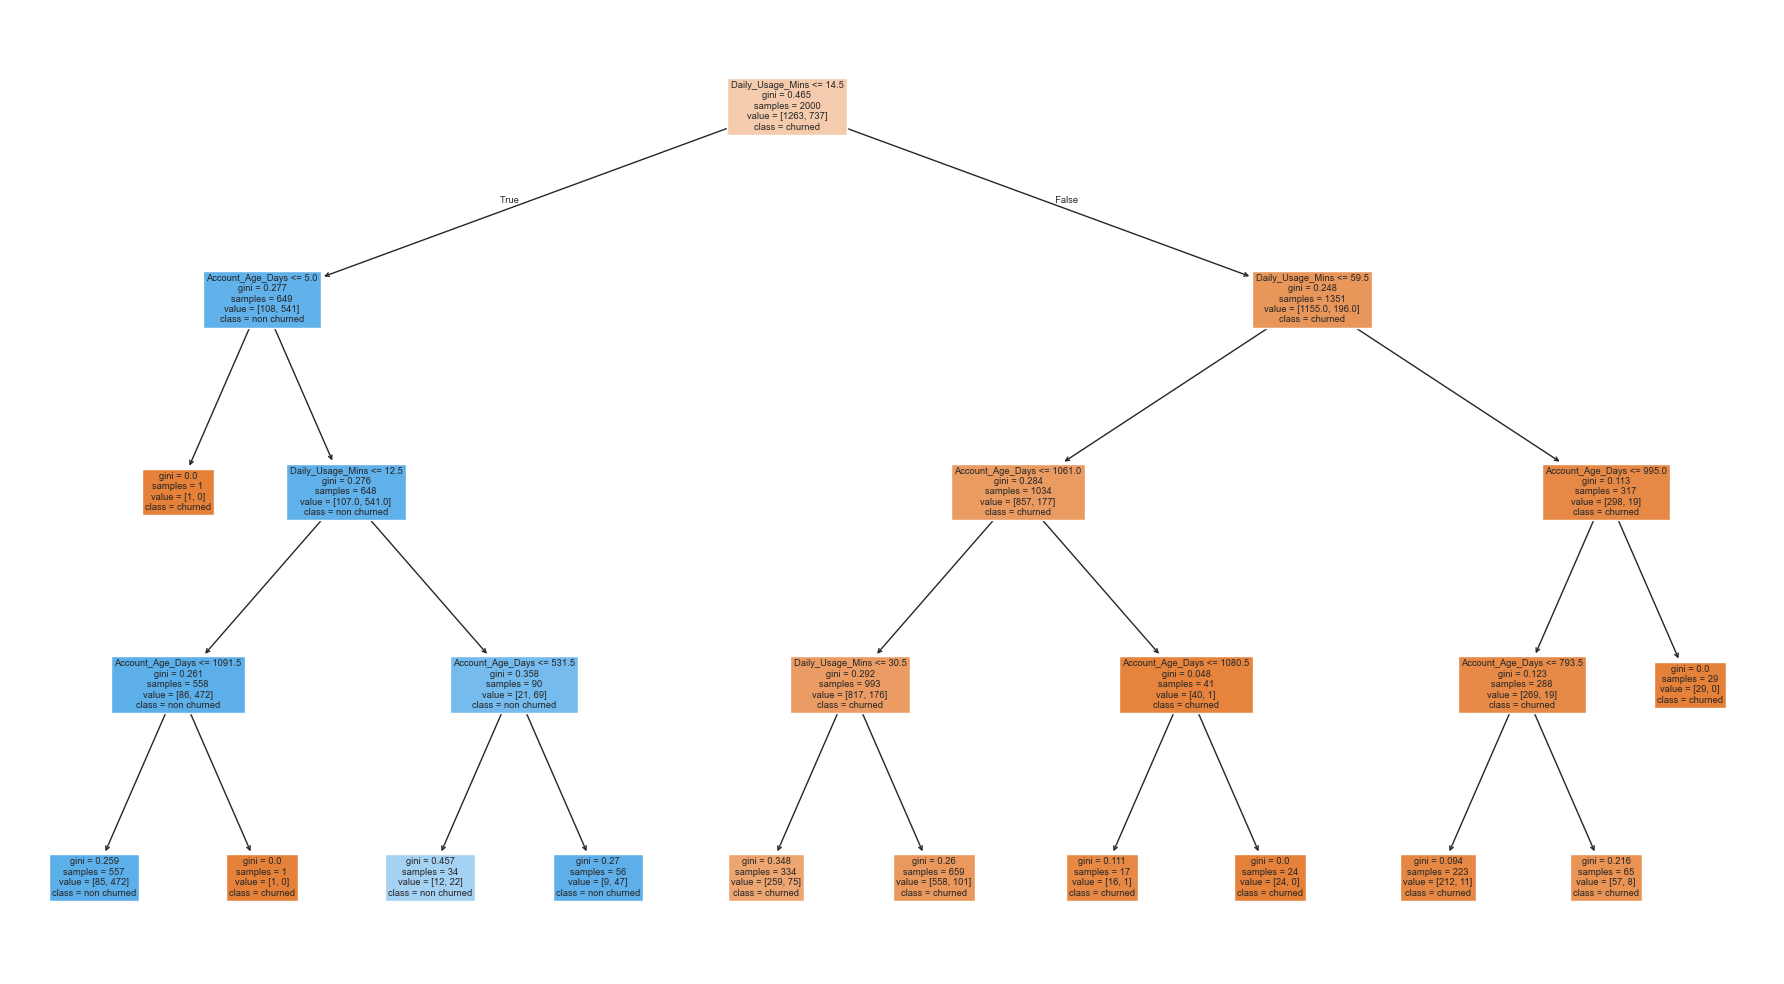

In [67]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(18, 10))
plot_tree(
    dc,
    feature_names=X.columns,
    class_names=["churned", "non churned"],
    filled=True
)

plt.tight_layout()

In [74]:
y_pred=dc.predict(X_test)
y_pred_train=dc.predict(X)
#checking overfitting
print("Precision:", precision_score(y,y_pred_train))
print("\t")
print("Recall:",recall_score(y_test,y_pred))
print("\t")
print("f1:",f1_score(y,y_pred_train))
print("\t")
print("accuracy:",accuracy_score(y,y_pred_train))
print("\t")
print("confusion_matrix:\n",confusion_matrix(y,y_pred_train))
print("\t")
print("roc_auc_score:\n",roc_auc_score(y,y_pred_train))
print("\t")
print("----Classification Report:----\n","\n",classification_report(y,y_pred_train))
print("\t")


Precision: 0.8361669242658424
	
Recall: 0.631578947368421
	
f1: 0.7817919075144508
	
accuracy: 0.849
	
confusion_matrix:
 [[1157  106]
 [ 196  541]]
	
roc_auc_score:
 0.8250649151134846
	
----Classification Report:----
 
               precision    recall  f1-score   support

           0       0.86      0.92      0.88      1263
           1       0.84      0.73      0.78       737

    accuracy                           0.85      2000
   macro avg       0.85      0.83      0.83      2000
weighted avg       0.85      0.85      0.85      2000

	


#### We checked for overfitting of the data in decision tree

#### classification parameters is almost similiar with test data and train data showing no big difference hence no overfit

In [77]:
from sklearn.ensemble import RandomForestClassifier

rf=RandomForestClassifier( n_estimators=501,max_depth=4,oob_score=True,random_state =42 )
rf.fit(X,y)

y_pred=rf.predict(X_test)
print("Precision:", precision_score(y_test,y_pred))
print("\t")
print("Recall:",recall_score(y_test,y_pred))
print("\t")
print("f1:",f1_score(y_test,y_pred))
print("\t")
print("accuracy:",accuracy_score(y_test,y_pred))
print("\t")
print("OOB_SCORE" ,rf.oob_score_*100,"%")
print("\t")
print("confusion_matrix:\n",confusion_matrix(y_test,y_pred))
print("\t")

print("\t")
print("----Classification Report:----\n","\n",classification_report(y_test,y_pred))
print("\t")

Precision: 0.8074074074074075
	
Recall: 0.6374269005847953
	
f1: 0.7124183006535948
	
accuracy: 0.824
	
OOB_SCORE 84.8 %
	
confusion_matrix:
 [[303  26]
 [ 62 109]]
	
	
----Classification Report:----
 
               precision    recall  f1-score   support

           0       0.83      0.92      0.87       329
           1       0.81      0.64      0.71       171

    accuracy                           0.82       500
   macro avg       0.82      0.78      0.79       500
weighted avg       0.82      0.82      0.82       500

	


#### OOB score is approximatly same as the accuracy score demonstrating that the data is not overfit

In [70]:
y_pred

array([0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1,
       0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1,
       1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1,
       1, 0, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0,
       1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 1, 0,
       0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 1, 0, 0,
       0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 1,
       0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0,
       0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0,
       1, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0,
       1, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 1, 0, 0,

In [78]:
from sklearn.svm import SVC
svm_model=SVC()
svm_model.fit(X,y)

y_pred=svm_model.predict(X_test)

print("Precision:", precision_score(y_test,y_pred))
print("\t")
print("Recall:",recall_score(y_test,y_pred))
print("\t")
print("f1:",f1_score(y_test,y_pred))
print("\t")
print("accuracy:",accuracy_score(y_test,y_pred))
print("\t")
print("confusion_matrix:\n",confusion_matrix(y_test,y_pred))
print("\t")
print("roc_auc_score:\n",roc_auc_score(y_test,y_pred))
print("\t")
print("----Classification Report:----\n","\n",classification_report(y_test,y_pred))
print("\t")

Precision: 0.6477987421383647
	
Recall: 0.6023391812865497
	
f1: 0.6242424242424243
	
accuracy: 0.752
	
confusion_matrix:
 [[273  56]
 [ 68 103]]
	
roc_auc_score:
 0.7160632076645514
	
----Classification Report:----
 
               precision    recall  f1-score   support

           0       0.80      0.83      0.81       329
           1       0.65      0.60      0.62       171

    accuracy                           0.75       500
   macro avg       0.72      0.72      0.72       500
weighted avg       0.75      0.75      0.75       500

	


In [79]:
from sklearn.ensemble import GradientBoostingClassifier
gbc=GradientBoostingClassifier(n_estimators=201,learning_rate=0.1)
gbc.fit(X,y)

y_pred=gbc.predict(X_test)
print("Precision:", precision_score(y_test,y_pred))
print("\t")
print("Recall:",recall_score(y_test,y_pred))
print("\t")
print("f1:",f1_score(y_test,y_pred))
print("\t")
print("accuracy:",accuracy_score(y_test,y_pred))
print("\t")
print("confusion_matrix:\n",confusion_matrix(y_test,y_pred))
print("\t")
print("roc_auc_score:\n",roc_auc_score(y_test,y_pred))
print("\t")
print("----Classification Report:----\n","\n",classification_report(y_test,y_pred))
print("\t")



Precision: 0.7753623188405797
	
Recall: 0.6257309941520468
	
f1: 0.6925566343042071
	
accuracy: 0.81
	
confusion_matrix:
 [[298  31]
 [ 64 107]]
	
roc_auc_score:
 0.7657530350699443
	
----Classification Report:----
 
               precision    recall  f1-score   support

           0       0.82      0.91      0.86       329
           1       0.78      0.63      0.69       171

    accuracy                           0.81       500
   macro avg       0.80      0.77      0.78       500
weighted avg       0.81      0.81      0.80       500

	


#### Best performing model -- Random Forest 
 Accuracy - 82%
 F1 Score - 71%
 Precision- 80%
 ROC_AUC  - 77.9% ~ 78%

#### Q1 - How does churn rate vary across contract types month-month , annual , Biennial

==== 1.If we consider users account age less then 30 as monthly user we can say their is high risk of churning 

==== 2.User with atleast 6 months of usage are less prone to get churned away

==== 3.user having account age greater then 1 year can be consider to be having annual contract and might have built a habit to use the service 

==== 4.user with more the around 2 year account age might have used the biennial contract and now they are having the minimum of get churned as compare to a new user



C:\Users\AVNEET\AppData\Local\Temp\ipykernel_3052\3044434801.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  churn_by_bin = dataset_duplicate.groupby('Bin')['Churn'].mean()


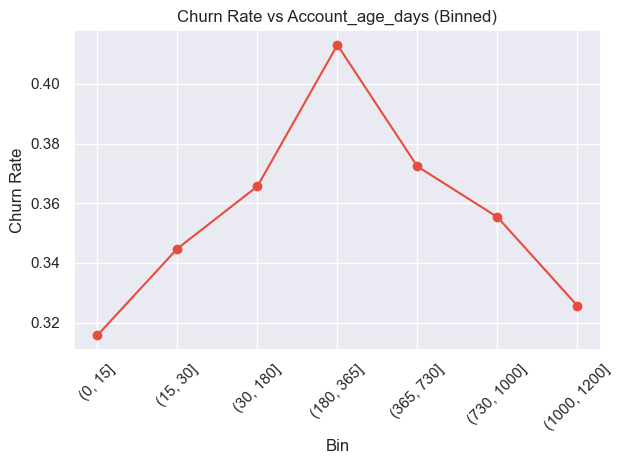

In [82]:
dataset_duplicate['Bin'] = pd.cut(dataset_duplicate['Account_Age_Days'], bins=[0,15,30,180,365,730,1000,1200])   

churn_by_bin = dataset_duplicate.groupby('Bin')['Churn'].mean()
plt.figsize= (8,6)
churn_by_bin.plot(kind='line', marker='o', color='#e74c3c')
plt.title('Churn Rate vs Account_age_days (Binned)')
plt.ylabel('Churn Rate')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#### Q2 - Distribution tenure difference between churned and retained user

==== Tenure distribution is somewhat uniform only 
Where active users have higher count 
users with acc_age greater then 800 are majorly active users 
we still have users who are getting churned even after having acc_age greater then 800 

Mean acc age Of Active Users:  568.492478226445 days
Number of retained users:  1263
Mean Usage Time Of Active Users:  47.68250197941409 Mins


Number of Churned users:  737
Mean Usage Time Of Active Users:  16.416553595658073 Mins
Mean acc age Of inActive Users:  548.0773405698778 day

Text(0.5, 1.0, 'InActive Users')

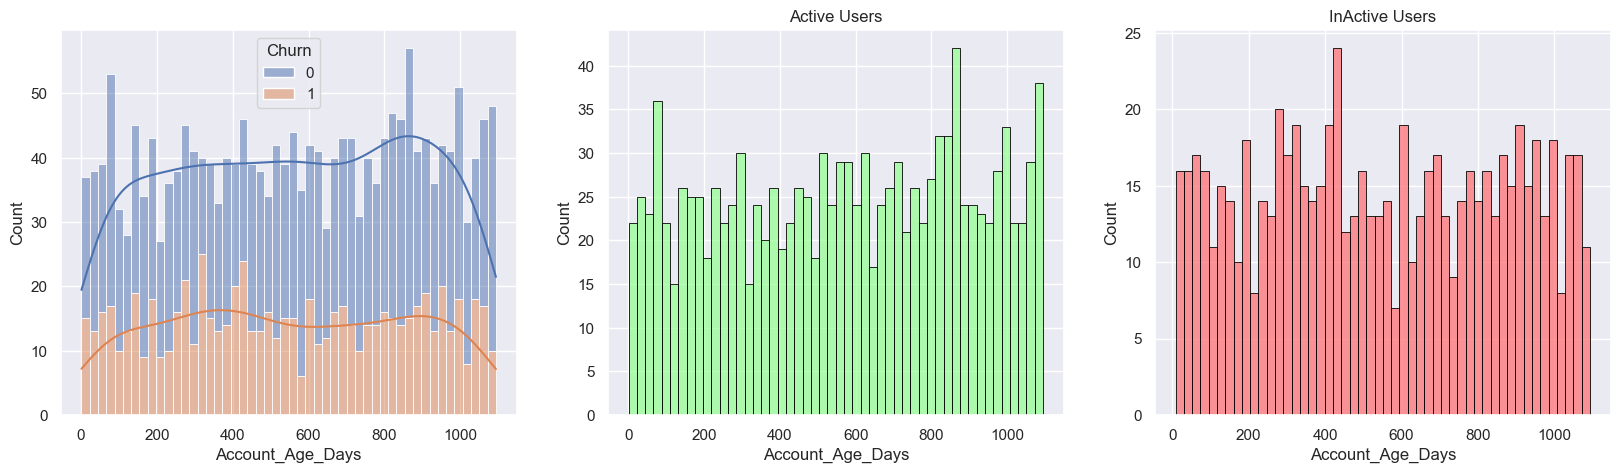

In [102]:
fig , ax= plt.subplots(1,3,figsize=(20, 5))

sns.histplot(
    data=dataset_duplicate,
    x="Account_Age_Days",
    bins=50,
    kde=True,
    multiple="stack",
    hue="Churn",
    ax=ax[0]
)
sns.histplot(
    data=active_dataset,
    x= "Account_Age_Days",
    edgecolor="black",
    color="#98FF98",
    bins=50,
    
    ax=ax[1]
)
ax[1].set_title("Active Users")

sns.histplot(
    data=inactive_dataset,
    x= "Account_Age_Days",
    edgecolor="black",
    color="#FF7276",
    bins=50,
    ax=ax[2]
)
ax[2].set_title("InActive Users")

#### Q6 - Tenure vs churn rate
 On increasing tenure churn rate decreases as seen in the line plot 
 around the tenure of 30-180m] days the churn rate reaches its maximum value that is ~ 0.41
 after this tenure the churn rate decreases


C:\Users\AVNEET\AppData\Local\Temp\ipykernel_3052\394100556.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  churn_by_bin = dataset_duplicate.groupby('Bin')['Churn'].mean()


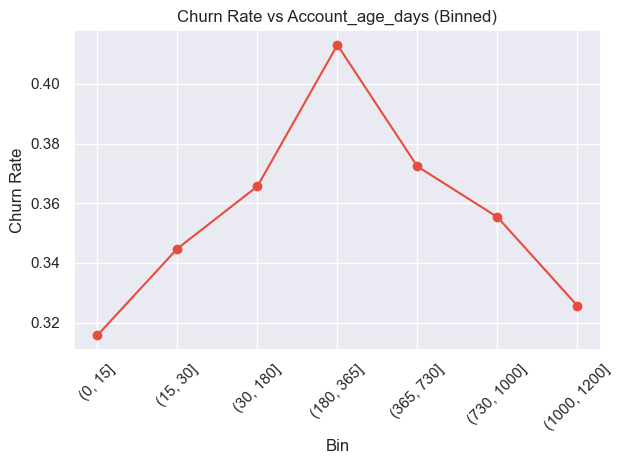

In [104]:
dataset_duplicate['Bin'] = pd.cut(dataset_duplicate['Account_Age_Days'], bins=[0,15,30,180,365,730,1000,1200])   

churn_by_bin = dataset_duplicate.groupby('Bin')['Churn'].mean()

churn_by_bin.plot(kind='line', marker='o', color='#e74c3c')
plt.title('Churn Rate vs Account_age_days (Binned)')
plt.ylabel('Churn Rate')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()